# Lab 2: Policy Gradient Methods

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

In this lab you will implement two foundational policy gradient algorithms:
- **REINFORCE** (Williams, 1992) — episodic Monte Carlo policy gradient with optional value baseline
- **PPO** (Schulman et al., 2017) — proximal policy optimization with clipped surrogate objective and GAE

The lab is divided into:
- **Part A** — Implementation (fill in the TODO sections)
- **Part B** — Experiments (run systematic evaluations and analyze results)

**Instructions:** Complete all cells marked with `# TODO`. Do not modify the provided helper code unless explicitly asked.

## Setup

Run the cell below to import all necessary libraries and verify your environment.

In [6]:
import os
import sys
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

# Import lab utilities
from networks import DiscreteActorCritic
from utils import compute_returns, compute_gae, RolloutBuffer

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Resolve experiments directory relative to this notebook
_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f'Experiments directory: {EXPERIMENTS_DIR}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print('Setup complete!')

Using device: cuda
Experiments directory: /home/arviv790/Code/LiU/tdde78/labs/lab2_policy_gradient/experiments
Setup complete!


---

# Part A — Implementation

---

## A.1 — Explore the Environment

Before implementing the algorithms, let's understand the environment we will work with.

**CartPole-v1** — balance a pole on a cart by pushing left or right (discrete actions).

In [7]:
env_cp = gym.make('CartPole-v1')
print('=== CartPole-v1 ===')
print(f'  Observation space: {env_cp.observation_space}  shape={env_cp.observation_space.shape}')
print(f'  Action space:      {env_cp.action_space}')
obs, _ = env_cp.reset(seed=42)
print(f'  Sample obs: {obs}')
env_cp.close()

=== CartPole-v1 ===
  Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)  shape=(4,)
  Action space:      Discrete(2)
  Sample obs: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## A.2 — Actor-Critic Network

Open `networks.py` and implement `DiscreteActorCritic`.

It uses a **shared backbone** (2-layer MLP with Tanh) with separate **policy** and **value** heads:

```
state → Linear(64) → Tanh → Linear(64) → Tanh → [features]
                                                    ├── policy_head → logits (Categorical)
                                                    └── value_head  → V(s)
```

After implementing, run the test below.

In [8]:
# Test DiscreteActorCritic
from networks import DiscreteActorCritic

net_d = DiscreteActorCritic(state_dim=4, action_dim=2).to(device)
test_state = torch.randn(8, 4).to(device)
action, log_prob, entropy, value = net_d.get_action(test_state)

assert action.shape == (8,),    f'action shape should be (8,), got {action.shape}'
assert log_prob.shape == (8,),  f'log_prob shape should be (8,), got {log_prob.shape}'
assert entropy.shape == (8,),   f'entropy shape should be (8,), got {entropy.shape}'
assert value.shape == (8, 1),   f'value shape should be (8, 1), got {value.shape}'

# Test that providing an action gives the correct log_prob
fixed_action = torch.zeros(8, dtype=torch.long).to(device)
_, lp_fixed, _, _ = net_d.get_action(test_state, fixed_action)
assert lp_fixed.shape == (8,)

n_params = sum(p.numel() for p in net_d.parameters())
print(f'DiscreteActorCritic: action={action.shape}, log_prob={log_prob.shape}, '
      f'entropy={entropy.shape}, value={value.shape}, params={n_params:,}')
print('DiscreteActorCritic test passed!')

DiscreteActorCritic: action=torch.Size([8]), log_prob=torch.Size([8]), entropy=torch.Size([8]), value=torch.Size([8, 1]), params=4,675
DiscreteActorCritic test passed!


## A.3 — Utility Functions

`utils.py` is fully provided — no implementation needed.

It contains:
- `compute_returns(rewards, gamma)` — Monte Carlo discounted returns
- `compute_gae(rewards, values, dones, last_value, gamma, gae_lambda)` — GAE advantages
- `RolloutBuffer` — rollout storage with GAE computation and mini-batch sampling

Run the tests below to verify the utilities work correctly.

In [9]:
# Test compute_returns
from utils import compute_returns

# Simple episode: [1, 1, 1] with gamma=0.99
# G_0 = 1 + 0.99 + 0.99^2 = 2.9701
# G_1 = 1 + 0.99           = 1.99
# G_2 = 1
test_rewards = [1.0, 1.0, 1.0]
returns = compute_returns(test_rewards, gamma=0.99)

assert returns.shape == (3,), f'Expected shape (3,), got {returns.shape}'
assert returns.dtype == np.float32, f'Expected float32, got {returns.dtype}'
assert abs(returns[2] - 1.0) < 1e-5, f'G_2 should be 1.0, got {returns[2]}'
assert abs(returns[1] - 1.99) < 1e-4, f'G_1 should be 1.99, got {returns[1]}'
assert abs(returns[0] - 2.9701) < 1e-4, f'G_0 should be 2.9701, got {returns[0]}'
print(f'compute_returns: {returns}  (expected [2.970, 1.990, 1.000])')
print('compute_returns test passed!')

compute_returns: [2.9701 1.99   1.    ]  (expected [2.970, 1.990, 1.000])
compute_returns test passed!


In [10]:
# Test compute_gae
from utils import compute_gae

rewards = [1.0, 1.0, 1.0]
values  = [0.5, 0.5, 0.5]
dones   = [False, False, True]  # episode ends at last step
advantages, returns = compute_gae(rewards, values, dones,
                                   last_value=0.0, gamma=0.99, gae_lambda=0.95)

assert advantages.shape == (3,), f'Expected shape (3,), got {advantages.shape}'
assert returns.shape == (3,),    f'Expected shape (3,), got {returns.shape}'
assert advantages.dtype == np.float32
# Returns should be close to advantages + values
np.testing.assert_allclose(returns, advantages + np.array(values, dtype=np.float32), rtol=1e-5)
print(f'advantages: {advantages}')
print(f'returns:    {returns}')
print('compute_gae test passed!')

advantages: [2.3730676 1.46525   0.5      ]
returns:    [2.8730676 1.96525   1.       ]
compute_gae test passed!


In [11]:
# Test RolloutBuffer
from utils import RolloutBuffer

buf = RolloutBuffer(n_steps=100, state_dim=4, action_dim=2, is_continuous=False)

for i in range(60):
    state    = np.random.randn(4).astype(np.float32)
    action   = np.random.randint(0, 2)
    reward   = float(np.random.randn())
    done     = (i % 20 == 19)
    log_prob = float(np.random.randn())
    value    = float(np.random.randn())
    buf.store(state, action, reward, done, log_prob, value)

assert len(buf) == 60, f'Expected 60, got {len(buf)}'

buf.compute_returns_and_advantages(last_value=0.0, gamma=0.99, gae_lambda=0.95)
assert buf.advantages is not None, 'advantages not set'
assert buf.returns is not None,    'returns not set'

batches = list(buf.get_batches(batch_size=16))
assert len(batches) >= 3, f'Expected >=3 batches, got {len(batches)}'
states_b, actions_b, log_probs_b, advs_b, rets_b, old_vals_b = batches[0]
assert states_b.shape[1] == 4,        f'State dim should be 4, got {states_b.shape[1]}'
assert actions_b.dtype == torch.int64, f'Discrete actions should be int64'
print(f'Batch shapes: states={states_b.shape}, actions={actions_b.shape}, '
      f'adv={advs_b.shape}, returns={rets_b.shape}')
print('RolloutBuffer test passed!')


Batch shapes: states=torch.Size([16, 4]), actions=torch.Size([16]), adv=torch.Size([16]), returns=torch.Size([16])
RolloutBuffer test passed!


## A.4 — REINFORCE Agent

Implement the REINFORCE agent below.

The agent collects **complete episodes** and updates the policy using:

**With baseline** (`use_baseline=True`):
$$\mathcal{L}(\theta) = -\frac{1}{T} \sum_t \log \pi_\theta(a_t \mid s_t) \cdot \hat{A}_t + c_V \cdot \mathcal{L}_V$$
where $\hat{A}_t = G_t - V(s_t)$ and $\mathcal{L}_V = \text{MSE}(V(s_t),\, G_t)$.

**Without baseline** (`use_baseline=False`):
$$\mathcal{L}(\theta) = -\frac{1}{T} \sum_t \log \pi_\theta(a_t \mid s_t) \cdot G_t$$
No value loss — $c_V \cdot \mathcal{L}_V = 0$.

In [12]:
class REINFORCEAgent:
    """
    REINFORCE agent with optional learned baseline.

    Args:
        state_dim    (int):   Dimension of state space.
        action_dim   (int):   Number of discrete actions.
        lr           (float): Learning rate.
        gamma        (float): Discount factor.
        use_baseline (bool):  If True, subtract V(s_t) from returns.
        value_coef   (float): Coefficient for value loss.
        seed         (int):   Random seed.
    """

    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 use_baseline=True, value_coef=0.5, seed=42):
        self.gamma = gamma
        self.use_baseline = use_baseline
        self.value_coef = value_coef

        # =====================================================================
        # TODO: Initialize the network and optimizer.
        #   - Create a DiscreteActorCritic network and move it to device.
        #   - Create an Adam optimizer for the network parameters.
        # =====================================================================
        self.network = DiscreteActorCritic(state_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=lr)


    def select_action(self, state):
        """Sample an action stochastically (no gradient)."""
        # =====================================================================
        # TODO: Select an action without computing gradients.
        #   - Convert the numpy state to a float tensor and add a batch dimension.
        #   - Use torch.no_grad() when calling the network — we are collecting
        #     data, not training.
        #   - Return the action and its log probability as Python scalars.
        # =====================================================================
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        
        with torch.no_grad():
            action, log_prob, _, _ = self.network.get_action(state)
            
        return action.item(), log_prob.item()
        

    def update(self, states, actions, rewards):
        """
        Perform one gradient update on a complete episode.

        Returns:
            pg_loss (float), value_loss (float)
        """
        # =====================================================================
        # TODO: Implement the REINFORCE gradient update.
        #
        # Step 1 — Compute discounted returns.
        #   Use compute_returns() to get G_t for each timestep.
        #   Convert to a float tensor. Also compute a normalized copy of the
        #   returns for stable value function training (zero mean, unit std).
        #   Skip normalization if the episode has only one step.
        returns = compute_returns(rewards, self.gamma)
        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        
        if len(returns) > 1: #if there is more than 1 timestep in episode
            returns_norm = (returns - returns.mean()) / (returns.std() + 1e-8) #+1e-8 to avoid division by zero, value chosen because it's default in Adam according to PyTorch docs
        else:
            returns_norm = returns
        
        # Step 2 — Re-evaluate actions under the current policy WITH gradients.
        #   Convert states and actions to tensors, then call get_action() so
        #   that log_probs and values are part of the computation graph.
        #   Squeeze the value head output to remove the trailing dimension.
        states = torch.tensor(states, dtype=torch.float32, device=device)
        actions = torch.tensor(actions, dtype=torch.long, device=device)
        
        _, log_probs, _, values = self.network.get_action(states, actions)
        values = values.squeeze(-1) #-1 = last dimension
        
        
        # Step 3 — Compute advantages and value loss.
        #   If use_baseline=True:
        #     Advantage = raw return minus the value baseline (detached).
        #     Normalize the advantages for gradient stability.
        #     Value loss = MSE between predicted values and normalized returns.
        #   If use_baseline=False:
        #     Advantage = normalized returns (no baseline subtraction).
        #     Value loss = 0  (the value head is not trained).
        if self.use_baseline:
            advantages = returns - values.detach()
            
            if len(advantages) > 1: #like before, if more than 1 timestep in episode
                advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            
            value_loss = F.mse_loss(values, returns_norm)
        
        else: #no baseline
            advantages = returns_norm
            value_loss = torch.tensor(0.0, device=device) #Cast to pytorch scalar tensor to not break calculations
        
        # Step 4 — Policy gradient loss.
        #   L_pg = -mean( log_prob * advantage )  over all timesteps.
        pg_loss = (-1.0) * torch.mean(log_probs * advantages)
        
        # Step 5 — Total loss and optimizer step.
        #   Combine policy loss and value loss, backpropagate, clip gradients
        #   (max norm 0.5), and step the optimizer.
        #   Return both losses as Python floats.
        loss = pg_loss + self.value_coef * value_loss
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
        self.optimizer.step()
        
        return pg_loss.item(), value_loss.item()
        # =====================================================================

print("REINFORCEAgent class defined!")


REINFORCEAgent class defined!


## A.5 — REINFORCE Training Loop

Implement the full training loop for REINFORCE. The loop collects one **complete episode** per iteration and calls `agent.update()` at the end.

In [13]:
def train_reinforce(env_name='CartPole-v1', num_episodes=600, lr=1e-3,
                    gamma=0.99, use_baseline=True, value_coef=0.5,
                    seed=42, solve_threshold=None):
    """
    Train a REINFORCE agent.

    Args:
        env_name        (str):   Gymnasium environment name.
        num_episodes    (int):   Maximum number of training episodes.
        lr              (float): Learning rate.
        gamma           (float): Discount factor.
        use_baseline    (bool):  Whether to use the value baseline.
        value_coef      (float): Coefficient for value loss.
        seed            (int):   Random seed.
        solve_threshold (float): Stop early when avg reward (last 100 eps) >= this.

    Returns:
        dict with keys: episode_rewards, episode_lengths, pg_losses, value_losses, agent
    """
    set_seed(seed)
    env = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = REINFORCEAgent(state_dim, action_dim, lr=lr, gamma=gamma,
                           use_baseline=use_baseline, value_coef=value_coef, seed=seed)

    episode_rewards, episode_lengths, pg_losses, value_losses = [], [], [], []

    # =========================================================================
    # TODO: Implement the REINFORCE episode loop.
    #
    # For each episode:
    #   1. Reset the environment with a per-episode seed for reproducibility.
    #   2. Collect a full episode by stepping through the environment:
    #        select an action, observe the next state and reward, and record
    #        states, actions, and rewards until the episode terminates.
    #   3. Call agent.update() on the collected episode data.
    #   4. Track episode reward, episode length, and both losses.
    #   5. Print a progress summary every 50 episodes (average reward and loss).
    #   6. Stop early if the rolling average over the last 100 episodes
    #      reaches solve_threshold (when solve_threshold is not None).
    # =========================================================================
    for episode in range(num_episodes):
        state, _ = env.reset(seed=(seed+episode))
        
        #Init stuff
        actions, states, rewards = [],[],[]
        ep_done = False
        ep_reward = 0
        ep_length = 0
        
        #Collect full episode and stop episode when finished our
        while not ep_done:
            action, _ = agent.select_action(state)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_done = terminated or truncated #terminated = reached terminal state, truncated = reached time limit or got out of bounds. Either way we want to reset the episode here.
            
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            
            state = next_state
            ep_reward += reward
            ep_length += 1
        
        #Update our agent
        pg_loss, value_loss = agent.update(states, actions, rewards)
        
        #Track stuff
        episode_rewards.append(ep_reward)
        episode_lengths.append(ep_length)
        pg_losses.append(pg_loss)
        value_losses.append(value_loss)
        
        #Print progress summary every 50 episodes
        if (episode+1) % 50 == 0: #I use numpy here instead of pytorch because we're not working with tensors for the data below
            avg_reward = np.mean(episode_rewards[-50:])
            avg_pg_loss = np.mean(pg_losses[-50:])
            avg_value_loss = np.mean(value_losses[-50:])
            print(f"Episode: {episode+1} | Average reward: {avg_reward:.3f}\nPG loss: {avg_pg_loss:.3f} | Value loss: {avg_value_loss:.3f}")

        #Stop early if last 100 episodes had average over solve treshhold
        if solve_threshold is not None and len(episode_rewards) >= 100:
            avg_last_100 = np.mean(episode_rewards[-100:])
            if avg_last_100 >= solve_threshold:
                print(f"Solved at episode {episode+1} with average reward{avg_last_100:.3f}")
                break

    env.close()
    return {'episode_rewards': episode_rewards, 'episode_lengths': episode_lengths,
            'pg_losses': pg_losses, 'value_losses': value_losses, 'agent': agent}

print("train_reinforce defined!")


train_reinforce defined!


## A.6 — Plotting Utilities

Helper functions for visualizing training results. No changes needed here.

In [14]:
def _save_plot(fig, title):
    try:
        plots_dir = os.path.join(EXPERIMENTS_DIR, 'plots')
        os.makedirs(plots_dir, exist_ok=True)
        fname = title.lower().replace(' ', '_').replace('/', '_').replace('—', '').replace(':', '').strip('_') + '.png'
        fig.savefig(os.path.join(plots_dir, fname), dpi=150, bbox_inches='tight')
        print(f'Plot saved: {os.path.join(plots_dir, fname)}')
    except Exception as e:
        print(f'Could not save plot: {e}')


def plot_reinforce_results(results, title='REINFORCE Training', window=50):
    """Plot REINFORCE training curves (episode-based)."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    rewards = results['episode_rewards']

    axes[0].plot(rewards, alpha=0.3, color='blue', label='Raw')
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
        axes[0].plot(range(window - 1, len(rewards)), ma, color='blue', label=f'{window}-ep avg')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')
    axes[0].set_title(f'{title} — Episode Rewards'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(results['pg_losses'], alpha=0.5, color='red')
    axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Policy Loss')
    axes[1].set_title(f'{title} — Policy Gradient Loss'); axes[1].grid(True, alpha=0.3)

    axes[2].plot(results['value_losses'], alpha=0.5, color='green')
    axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Value Loss')
    axes[2].set_title(f'{title} — Value Loss'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()


def plot_ppo_results(results, title='PPO Training', window=20):
    """Plot PPO training curves (update-based)."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    rewards = results['update_rewards']

    axes[0].plot(rewards, alpha=0.4, color='blue', label='Eval reward')
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
        axes[0].plot(range(window - 1, len(rewards)), ma, color='blue', label=f'{window}-update avg')
    axes[0].set_xlabel('PPO Update'); axes[0].set_ylabel('Reward')
    axes[0].set_title(f'{title} — Eval Reward'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(results['policy_losses'], alpha=0.5, color='red')
    axes[1].set_xlabel('PPO Update'); axes[1].set_ylabel('Policy Loss')
    axes[1].set_title(f'{title} — Policy Loss'); axes[1].grid(True, alpha=0.3)

    axes[2].plot(results['entropies'], alpha=0.5, color='purple')
    axes[2].set_xlabel('PPO Update'); axes[2].set_ylabel('Entropy')
    axes[2].set_title(f'{title} — Policy Entropy'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()


def plot_comparison(all_results, title='Comparison', window=50, x_label='Episode', reward_key='episode_rewards'):
    """Plot reward comparison across methods/seeds (mean ± std)."""
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, (name, results_list) in enumerate(all_results.items()):
        color = colors[idx % len(colors)]
        min_len = min(len(r[reward_key]) for r in results_list)
        all_rewards = np.array([r[reward_key][:min_len] for r in results_list])

        if min_len >= window:
            smoothed = np.array([np.convolve(row, np.ones(window) / window, mode='valid')
                                 for row in all_rewards])
            mean, std = smoothed.mean(axis=0), smoothed.std(axis=0)
            x = range(window - 1, min_len)
        else:
            mean, std = all_rewards.mean(axis=0), all_rewards.std(axis=0)
            x = range(min_len)

        ax.plot(x, mean, color=color, label=name)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_xlabel(x_label); ax.set_ylabel('Reward'); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()

print('Plotting utilities defined!')

Plotting utilities defined!


## A.7 — Train REINFORCE on CartPole-v1

Verify your REINFORCE implementation. The agent should reach average reward ≥ 475 within ~600 episodes.

Episode: 50 | Average reward: 26.840
PG loss: 0.000 | Value loss: 0.948
Episode: 100 | Average reward: 25.080
PG loss: -0.003 | Value loss: 0.890
Episode: 150 | Average reward: 33.020
PG loss: -0.009 | Value loss: 0.918
Episode: 200 | Average reward: 57.980
PG loss: -0.009 | Value loss: 0.984
Episode: 250 | Average reward: 103.140
PG loss: -0.017 | Value loss: 0.830
Episode: 300 | Average reward: 135.720
PG loss: -0.011 | Value loss: 0.680
Episode: 350 | Average reward: 198.260
PG loss: -0.016 | Value loss: 0.587
Episode: 400 | Average reward: 238.820
PG loss: -0.008 | Value loss: 1.120
Episode: 450 | Average reward: 240.480
PG loss: -0.014 | Value loss: 0.530
Episode: 500 | Average reward: 318.140
PG loss: -0.011 | Value loss: 0.705
Episode: 550 | Average reward: 293.060
PG loss: -0.012 | Value loss: 1.222
Episode: 600 | Average reward: 249.360
PG loss: -0.009 | Value loss: 1.144
Episode: 650 | Average reward: 378.900
PG loss: -0.013 | Value loss: 0.630
Episode: 700 | Average reward: 

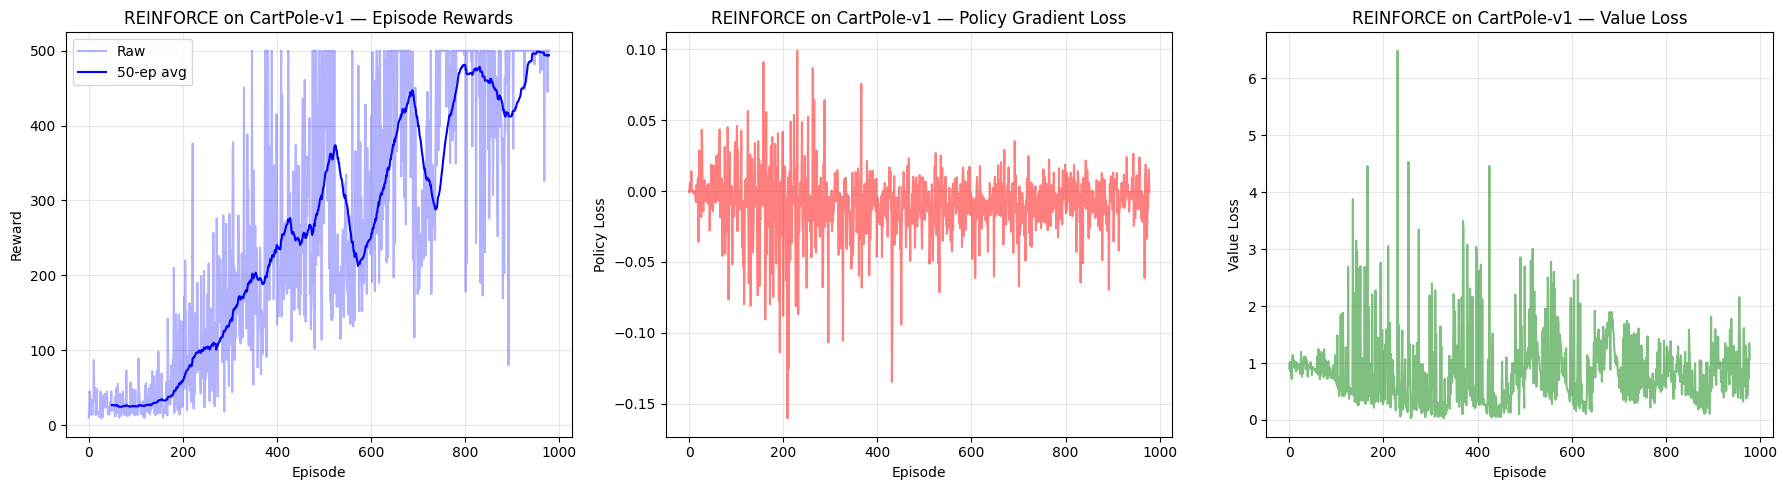


Average reward (last 100 eps): 475.7
CartPole SOLVED!


In [24]:
set_seed(42)
results_rf = train_reinforce(
    env_name='CartPole-v1',
    num_episodes=2000,
    lr=1e-3,
    use_baseline=True,
    solve_threshold=475,
    seed=42,
)

plot_reinforce_results(results_rf, title='REINFORCE on CartPole-v1')

avg = np.mean(results_rf['episode_rewards'][-100:])
print(f'\nAverage reward (last 100 eps): {avg:.1f}')
print('CartPole SOLVED!' if avg >= 475 else 'Not yet solved — check your implementation.')

## Visualise — REINFORCE Agent on CartPole-v1

In [25]:
def record_video(agent, env_name, video_dir, episode_trigger=lambda ep: ep == 0, seed=42):
    """Record one episode of the agent and return the video path."""
    os.makedirs(video_dir, exist_ok=True)
    env = gym.make(env_name, render_mode='rgb_array')
    env = gym.wrappers.RecordVideo(env, video_folder=video_dir,
                                   episode_trigger=episode_trigger,
                                   disable_logger=True)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    for _ in range(10000):
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            action, _, _, _ = agent.network.get_action(state_t)
        action_np = action.cpu().numpy().squeeze(0)
        obs, reward, terminated, truncated, _ = env.step(int(action_np))
        ep_reward += reward
        if terminated or truncated:
            break
    env.close()
    print(f'Episode reward: {ep_reward:.1f}')
    videos = sorted([f for f in os.listdir(video_dir) if f.endswith('.mp4')])
    return os.path.join(video_dir, videos[-1]) if videos else None


video_dir = os.path.join(EXPERIMENTS_DIR, 'videos', 'reinforce_cartpole')
video_path = record_video(results_rf['agent'], 'CartPole-v1', video_dir, seed=42)

if video_path:
    display(Video(video_path, embed=True, width=400))
else:
    print('No video found — check that ffmpeg is installed (sudo apt install ffmpeg).')

Episode reward: 500.0


## A.8 — PPO Agent

Implement the PPO agent. This is the core of the lab.

PPO operates in a **collect → update** cycle:
1. **collect_rollout**: gather `n_steps` transitions using the current policy, then compute GAE
2. **update**: run `n_epochs` passes over the rollout data with the clipped PPO objective

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t \left[ \min\left( r_t(\theta) A_t, \; \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon) A_t \right) \right]$$

In [ ]:
class PPOAgent:
    """
    PPO agent for discrete action spaces (CartPole-v1).

    Implements PPO-Clip (Schulman et al., 2017) with:
    - Clipped surrogate objective
    - GAE advantage estimation
    - Advantage normalization per mini-batch
    - Value loss clipping
    - Entropy bonus for exploration
    - Gradient norm clipping
    - Env state carried between rollouts (CleanRL-style)

    Args:
        state_dim     (int):   Dimension of state space.
        action_dim    (int):   Number of discrete actions.
        lr            (float): Learning rate.
        gamma         (float): Discount factor.
        gae_lambda    (float): GAE lambda (0=TD, 1=MC).
        clip_eps      (float): PPO clipping parameter epsilon.
        n_epochs      (int):   Update epochs per rollout.
        batch_size    (int):   Mini-batch size.
        value_coef    (float): Weight for value loss.
        entropy_coef  (float): Weight for entropy bonus.
        n_steps       (int):   Environment steps per rollout.
        max_grad_norm (float): Gradient clipping threshold.
        seed          (int):   Random seed.
    """

    def __init__(self, state_dim, action_dim,
                 lr=2.5e-4, gamma=0.99, gae_lambda=0.95, clip_eps=0.2,
                 n_epochs=4, batch_size=64, value_coef=0.5, entropy_coef=0.01,
                 n_steps=512, max_grad_norm=0.5, seed=42):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_eps = clip_eps
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.n_steps = n_steps
        self.max_grad_norm = max_grad_norm

        # =====================================================================
        # TODO: Initialize the buffer, network, and optimizer.
        #   - Create a RolloutBuffer for discrete actions (is_continuous=False).
        #   - Create a DiscreteActorCritic network and move it to device.
        #   - Create an Adam optimizer with eps=1e-5 (CleanRL standard).
        #   - Set self.obs = None  (will be initialized by train_ppo).
        # =====================================================================
        self.buffer = RolloutBuffer(self.n_steps, state_dim, action_dim, is_continuous=False)
        self.network = DiscreteActorCritic(state_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=lr, eps=1e-5)
        self.obs = None
        
    def select_action(self, state):
        """
        Sample an action from the current policy (no gradient).

        Returns:
            action_np (np.ndarray): Sampled action as numpy scalar.
            log_prob  (float):      Log probability of the action.
            value     (float):      State value estimate V(s).
        """
        # =====================================================================
        # TODO: Select an action without computing gradients.
        #   - Convert state to a float tensor and add a batch dimension.
        #   - Call the network inside torch.no_grad().
        #   - Convert the action to a numpy scalar (cpu, squeeze the batch dim).
        #   - Return the action array, log_prob, and value as Python scalars.
        # =====================================================================
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        
        with torch.no_grad():
            action, log_prob, _, value = self.network.get_action(state)
            action_np = action.cpu().numpy().squeeze()
            
        return action_np, log_prob.item(), value.item()
        

    def collect_rollout(self, env):
        """
        Collect n_steps transitions and compute GAE advantages.

        PPO collects a fixed number of steps rather than full episodes.
        self.obs carries the environment state across rollout boundaries so
        training is not interrupted at episode endings (CleanRL-style).

        Args:
            env: A Gymnasium environment instance.

        Returns:
            float: Mean episode reward over completed episodes in this rollout.
        """
        # =====================================================================
        # TODO: Collect exactly n_steps transitions into the rollout buffer.
        #
        # Step 1 — Clear the buffer at the start of each rollout.
        #
        # Step 2 — Step loop (repeat n_steps times):
        #   a. Select an action from self.obs using select_action().
        #   b. Step the environment to get the next observation, reward,
        #      and done flags (terminated or truncated).
        #   c. Store the transition in the buffer (current obs, action,
        #      reward, done, log_prob, value).
        #   d. Accumulate the episode reward and update self.obs.
        #   e. On episode end: record the completed episode reward,
        #      reset the counter, and reset the environment into self.obs.
        #
        # Step 3 — Bootstrap the value at the last step.
        #   After the loop, run the network on self.obs (no gradient) to get
        #   V(s_T). This is the bootstrap value for GAE at the rollout boundary.
        #
        # Step 4 — Compute GAE advantages.
        #   Call buffer.compute_returns_and_advantages() with the bootstrap value.
        #
        # Step 5 — Return the mean episode reward (or 0.0 if no episode finished).
        # =====================================================================
        self.buffer.clear()
        
        episode_rewards = []
        ep_reward = 0.0
         
        for i in range(self.n_steps):
            #Select action
            action, log_prob, value = self.select_action(self.obs)
            
            #Step environment
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            #Store transition in buffer
            self.buffer.store(self.obs, action, reward, done, log_prob, value)
            
            #Accumulate ep_reward and update self.obs
            ep_reward += reward
            self.obs = next_obs
            
            if done:
                episode_rewards.append(ep_reward)
                ep_reward = 0.0
                self.obs, _ = env.reset()
                
        with torch.no_grad():
            #Observation needs to be casted to tensor because get_action() expects tensor
            obs_tensor = torch.tensor(self.obs, dtype=torch.float32, device=device).unsqueeze(0)
            _, _, _, value = self.network.get_action(obs_tensor)
            
        bootstrap_value = value.item() #Cast to normal python number
        
        #Compute GAE advantages
        self.buffer.compute_returns_and_advantages(bootstrap_value, self.gamma, self.gae_lambda)
        
        #Return mean episode reward
        if len(episode_rewards) > 0:
            return np.mean(episode_rewards)
        else:
            return 0.0
            
            

    def update(self):
        """
        Run n_epochs of PPO updates over the collected rollout.

        Returns:
            Tuple of (mean_policy_loss, mean_value_loss, mean_entropy)
        """
        # =====================================================================
        # TODO: Implement the PPO mini-batch update loop.
        #
        # Repeat for n_epochs:
        #   For each mini-batch from the buffer:
        #
        #   Step 1 — Move all batch tensors to device.
        #
        #   Step 2 — Normalize advantages per mini-batch.
        #     Zero mean, unit std — this is standard in CleanRL PPO.
        #
        #   Step 3 — Re-evaluate the collected actions under the current policy.
        #     Get new log_probs, entropy, and values from the network.
        #
        #   Step 4 — PPO clipped surrogate loss.
        #     Compute the probability ratio r = exp(new_log_prob - old_log_prob).
        #     Clip r to [1-eps, 1+eps] and take the min of clipped and unclipped
        #     objectives. Negate to turn maximization into minimization.
        #
        #   Step 5 — Value loss with clipping.
        #     Compute unclipped MSE between new values and returns.
        #     Also compute clipped values (prevent large per-epoch value shifts)
        #     and take the max of the two losses (pessimistic bound).
        #
        #   Step 6 — Entropy bonus.
        #     Negate entropy to encourage exploration.
        #
        #   Step 7 — Combine losses, backpropagate, clip gradients, step optimizer.
        #     total = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss
        #
        # Return mean policy loss, value loss, and entropy across all mini-batches.
        # =====================================================================
        policy_losses, value_losses, entropies = [], [], []   
        advantages = torch.FloatTensor(self.buffer.advantages).to(device)
        #ADVANTAGE NORMALIZATION PER BATCH, I moved it here instead because it gave better training.
        if advantages.numel() > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        for i in range(self.n_epochs):
            for (states, actions, old_log_probs, advantages, returns, old_values) in self.buffer.get_batches(self.batch_size):
                #Move batch tensor to device
                states = states.to(device)
                actions = actions.to(device)
                old_log_probs = old_log_probs.to(device)
                advantages = advantages.to(device)
                returns = returns.to(device)
                old_values = old_values.to(device)
                
                #Advantage normalization per mini-batch, but I had to comment this out because it broke my training.
                #I moved it to the update() function above instead, making us normalize the entire batch instead of normalizing every mini-batch.
                #advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
                    
                #Get stuff from network
                _, new_log_probs, entropy, values = self.network.get_action(states, actions)
                values = values.squeeze(-1) #turn values shape from (batch_size, 1) --> (batch_size,)
                
                #Compute PPO clipped surrogate loss
                r = torch.exp(new_log_probs - old_log_probs)
                
                unclipped_r = r * advantages
                clipped_r = torch.clamp(r, 1.0 - self.clip_eps, 1.0 + self.clip_eps) * advantages
                
                policy_loss = -torch.mean(torch.min(unclipped_r, clipped_r))
                
                #Compute clipped value loss
                unclipped_value_loss = F.mse_loss(values, returns, reduction='none')
                
                clipped_pred_values = old_values + torch.clamp((values - old_values), -self.clip_eps, self.clip_eps)
                clipped_value_loss = F.mse_loss(clipped_pred_values, returns, reduction='none')
                
                value_loss = torch.mean(torch.max(unclipped_value_loss, clipped_value_loss))
                
                #Entropy bonus
                entropy_loss = (-1.0) * torch.mean(entropy)
                
                #Compute total loss, do backprop and step optimizer
                loss = policy_loss + self.value_coef * value_loss + self.entropy_coef * entropy_loss
                
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()
                
                #Track stuff
                policy_losses.append(policy_loss.item())
                value_losses.append(value_loss.item())
                entropies.append(torch.mean(entropy).item())
            
        return np.mean(policy_losses), np.mean(value_losses), np.mean(entropies)


print("PPOAgent class defined!")


PPOAgent class defined!


## A.9 — PPO Training Loop

Implement `train_ppo`. Unlike REINFORCE, PPO uses a fixed number of **rollout-update cycles** rather than episodes, so tracking is update-based.

In [33]:
def evaluate_ppo(agent, env, num_episodes=5, seed=0):
    """Evaluate a PPO agent (discrete actions)."""
    rewards = []
    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0.0
        for _ in range(10000):
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            with torch.no_grad():
                action, _, _, _ = agent.network.get_action(state_t)
            obs, reward, terminated, truncated, _ = env.step(int(action.item()))
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    return np.mean(rewards)


def train_ppo(env_name='CartPole-v1', num_updates=200, n_steps=512,
              seed=42, solve_threshold=None, anneal_lr=True, **agent_kwargs):
    """
    Train a PPO agent with optional linear LR annealing (CleanRL-style).

    Args:
        env_name        (str):  Gymnasium environment name.
        num_updates     (int):  Number of rollout-update cycles.
        n_steps         (int):  Environment steps per rollout.
        seed            (int):  Random seed.
        solve_threshold (float): Stop early when avg eval reward >= this.
        anneal_lr       (bool): Linearly decay LR from initial value to 0.
        **agent_kwargs:         Passed to PPOAgent (lr, gae_lambda, clip_eps, etc.)

    Returns:
        dict with keys: update_rewards, policy_losses, value_losses, entropies, agent
    """
    set_seed(seed)
    env = gym.make(env_name)
    eval_env = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = PPOAgent(state_dim, action_dim, n_steps=n_steps, seed=seed, **agent_kwargs)

    # Initialize env state — carried between rollouts (CleanRL-style)
    agent.obs, _ = env.reset(seed=seed)

    # Linear LR annealing: lr * (1 - update / num_updates) — same as CleanRL
    if anneal_lr:
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            agent.optimizer,
            lr_lambda=lambda step: 1.0 - step / num_updates
        )

    update_rewards, policy_losses, value_losses, entropies = [], [], [], []

    # =========================================================================
    # TODO: Implement the PPO update loop.
    #
    # For each update:
    #   1. Collect a rollout using the agent. The agent's internal obs is
    #      updated automatically — no manual env reset needed here.
    #   2. Run the PPO update on the collected rollout.
    #   3. Step the LR scheduler (if annealing is enabled).
    #   4. Evaluate the current policy on the eval environment and record
    #      the mean reward.
    #   5. Track policy loss, value loss, and entropy.
    #   6. Print a progress line every 20 updates showing the rolling average
    #      eval reward and current learning rate.
    #   7. Stop early if the rolling average over the last 10 updates
    #      reaches solve_threshold (when solve_threshold is not None).
    # =========================================================================
    for update in range(num_updates):
        #Collect rollout
        rollout_reward = agent.collect_rollout(env)
        
        #Update agent
        policy_loss, value_loss, entropy = agent.update()
        
        #Step with scheduler if annealing enabled
        if anneal_lr:
            scheduler.step()
        
        #Evaluate current policy
        eval_reward = evaluate_ppo(agent, eval_env, seed=(seed+update))
        
        #Track stuff
        update_rewards.append(eval_reward)
        policy_losses.append(policy_loss)
        value_losses.append(value_loss)
        entropies.append(entropy)
        
        #Print progress every 20 updates
        if (update+1) % 20 == 0:
            avg_reward = np.mean(update_rewards[-20:])
            current_lr = agent.optimizer.param_groups[0]['lr']
            print(f"Update: {update+1} | Avg eval reward: {avg_reward:.3f} | LR: {current_lr:.6f}")
        
        #Stopping early if needed
        if solve_threshold is not None and len(update_rewards) >= 10:
            avg_last_10 = np.mean(update_rewards[-10:])
            if avg_last_10 >= solve_threshold:
                print(f"Solved at update {update+1} with average reward: {avg_last_10:.3f}")
                break

    env.close()
    eval_env.close()
    return {'update_rewards': update_rewards, 'policy_losses': policy_losses,
            'value_losses': value_losses, 'entropies': entropies, 'agent': agent}

print("train_ppo and evaluate_ppo defined!")

train_ppo and evaluate_ppo defined!


## A.10 — Train PPO on CartPole-v1

Verify your PPO implementation on CartPole.

Update: 20 | Avg eval reward: 163.150 | LR: 0.000294
Update: 40 | Avg eval reward: 144.800 | LR: 0.000288
Update: 60 | Avg eval reward: 121.290 | LR: 0.000282
Update: 80 | Avg eval reward: 128.070 | LR: 0.000276
Update: 100 | Avg eval reward: 144.280 | LR: 0.000270
Update: 120 | Avg eval reward: 178.240 | LR: 0.000264
Update: 140 | Avg eval reward: 298.440 | LR: 0.000258
Solved at update 149 with average reward: 475.880
Plot saved: /home/arviv790/Code/LiU/tdde78/labs/lab2_policy_gradient/experiments/plots/ppo_on_cartpole-v1.png


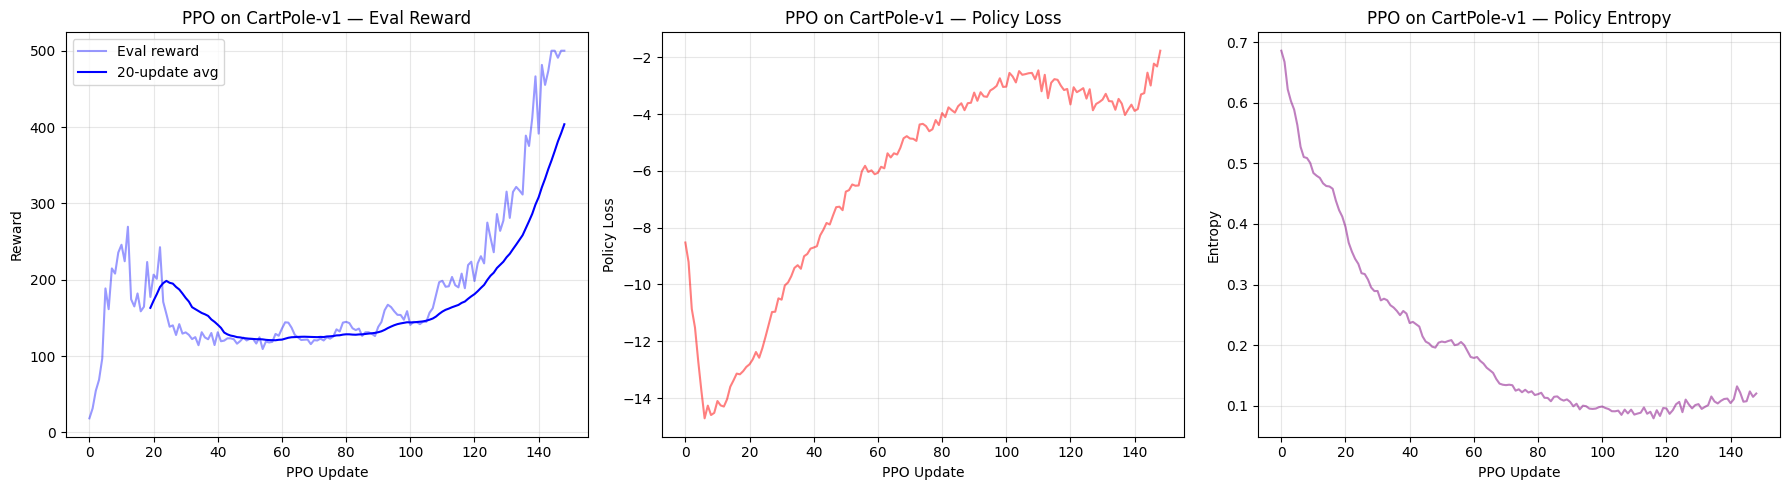


Average eval reward (last 10 updates): 475.9
CartPole SOLVED!


In [34]:
set_seed(42)
results_ppo_cp = train_ppo(
    env_name='CartPole-v1',
    num_updates=1000,
    n_steps=2048,
    solve_threshold=475,
    seed=42,
    lr=3e-4,
    gae_lambda=0.95,
    clip_eps=0.2,
    n_epochs=4,
    batch_size=64,
    entropy_coef=0.01,
)

plot_ppo_results(results_ppo_cp, title='PPO on CartPole-v1')

avg = np.mean(results_ppo_cp['update_rewards'][-10:])
solved = avg >= 475 or len(results_ppo_cp['update_rewards']) < 1000
print(f'\nAverage eval reward (last 10 updates): {avg:.1f}')
print('CartPole SOLVED!' if solved else 'Not yet solved — check your implementation.')

## Visualise — PPO Agent on CartPole-v1

In [22]:
video_dir = os.path.join(EXPERIMENTS_DIR, 'videos', 'ppo_cartpole')
video_path = record_video(results_ppo_cp['agent'], 'CartPole-v1', video_dir, seed=42)

if video_path:
    display(Video(video_path, embed=True, width=400))
else:
    print('No video found — check that ffmpeg is installed (sudo apt install ffmpeg).')

Episode reward: 500.0


---

# Part B — Experiments

---

Now that your implementation works, run systematic experiments to understand the algorithms.

**Important:** For all experiments, run at least **3 different seeds** and report mean ± std.

## B.1 — Ablation: Baseline in REINFORCE

Does the value baseline actually help? Compare REINFORCE with and without the baseline
on CartPole-v1 with 3 seeds.

- `use_baseline=True` — subtracts V(s) from returns as advantage
- `use_baseline=False` — uses normalized returns directly

Run `num_episodes=2000` with seeds `[42, 123, 456]`.

Episode: 50 | Average reward: 26.840
PG loss: 0.000 | Value loss: 0.948
Episode: 100 | Average reward: 25.080
PG loss: -0.003 | Value loss: 0.890
Episode: 150 | Average reward: 33.020
PG loss: -0.009 | Value loss: 0.918
Episode: 200 | Average reward: 57.980
PG loss: -0.009 | Value loss: 0.984
Episode: 250 | Average reward: 103.140
PG loss: -0.017 | Value loss: 0.830
Episode: 300 | Average reward: 135.720
PG loss: -0.011 | Value loss: 0.680
Episode: 350 | Average reward: 198.260
PG loss: -0.016 | Value loss: 0.587
Episode: 400 | Average reward: 238.820
PG loss: -0.008 | Value loss: 1.120
Episode: 450 | Average reward: 240.480
PG loss: -0.014 | Value loss: 0.530
Episode: 500 | Average reward: 318.140
PG loss: -0.011 | Value loss: 0.705
Episode: 550 | Average reward: 293.060
PG loss: -0.012 | Value loss: 1.222
Episode: 600 | Average reward: 249.360
PG loss: -0.009 | Value loss: 1.144
Episode: 650 | Average reward: 378.900
PG loss: -0.013 | Value loss: 0.630
Episode: 700 | Average reward: 

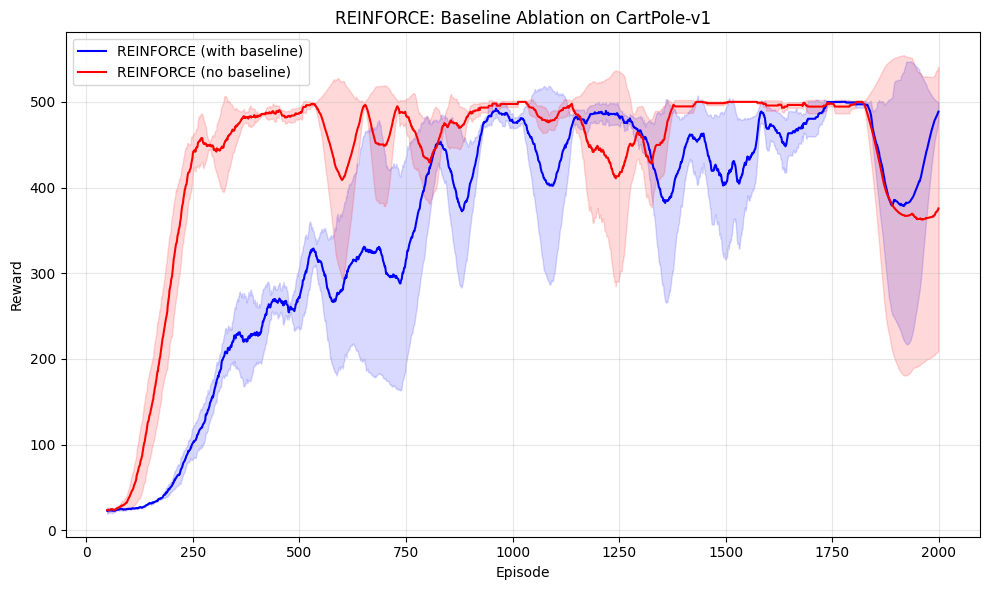

REINFORCE (with baseline): 444.7 ± 74.8
REINFORCE (no baseline): 369.3 ± 169.1


In [26]:
seeds = [42, 123, 456]

baseline_results = {
    'REINFORCE (with baseline)': [
        train_reinforce(env_name='CartPole-v1', num_episodes=2000, use_baseline=True, seed=s)
        for s in seeds
    ],
    'REINFORCE (no baseline)': [
        train_reinforce(env_name='CartPole-v1', num_episodes=2000, use_baseline=False, seed=s)
        for s in seeds
    ],
}

plot_comparison(baseline_results, title='REINFORCE: Baseline Ablation on CartPole-v1',
                window=50, x_label='Episode', reward_key='episode_rewards')

for name, results_list in baseline_results.items():
    final = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f'{name}: {np.mean(final):.1f} ± {np.std(final):.1f}')


## B.2 — Ablation: GAE Lambda (PPO on LunarLander-v3)

GAE interpolates between one-step TD ($\lambda = 0$, low variance, high bias)
and Monte Carlo ($\lambda = 1$, high variance, zero bias).

Test lambda values **0.0**, **0.95**, and **1.0** on **LunarLander-v3**
(`num_updates=600, n_steps=2048, n_epochs=4`) with seeds `[42, 123, 456]`.

Use `n_epochs=4` (standard PPO). Do **not** set `solve_threshold` so you see
the full 600-update learning curve.

Which $\lambda$ works best and why?

Update: 20 | Avg eval reward: -197.754 | LR: 0.000280
Update: 40 | Avg eval reward: -164.216 | LR: 0.000260
Update: 60 | Avg eval reward: -145.310 | LR: 0.000240
Update: 80 | Avg eval reward: -126.733 | LR: 0.000220
Update: 100 | Avg eval reward: -110.384 | LR: 0.000200
Update: 120 | Avg eval reward: -57.936 | LR: 0.000180
Update: 140 | Avg eval reward: -26.336 | LR: 0.000160
Update: 160 | Avg eval reward: 7.886 | LR: 0.000140
Update: 180 | Avg eval reward: -2.009 | LR: 0.000120
Update: 200 | Avg eval reward: -42.784 | LR: 0.000100
Update: 220 | Avg eval reward: -24.259 | LR: 0.000080
Update: 240 | Avg eval reward: -0.323 | LR: 0.000060
Update: 260 | Avg eval reward: 25.502 | LR: 0.000040
Update: 280 | Avg eval reward: 35.601 | LR: 0.000020
Update: 300 | Avg eval reward: 30.266 | LR: 0.000000
Update: 20 | Avg eval reward: -242.336 | LR: 0.000280
Update: 40 | Avg eval reward: -148.071 | LR: 0.000260
Update: 60 | Avg eval reward: -145.202 | LR: 0.000240
Update: 80 | Avg eval reward: -115

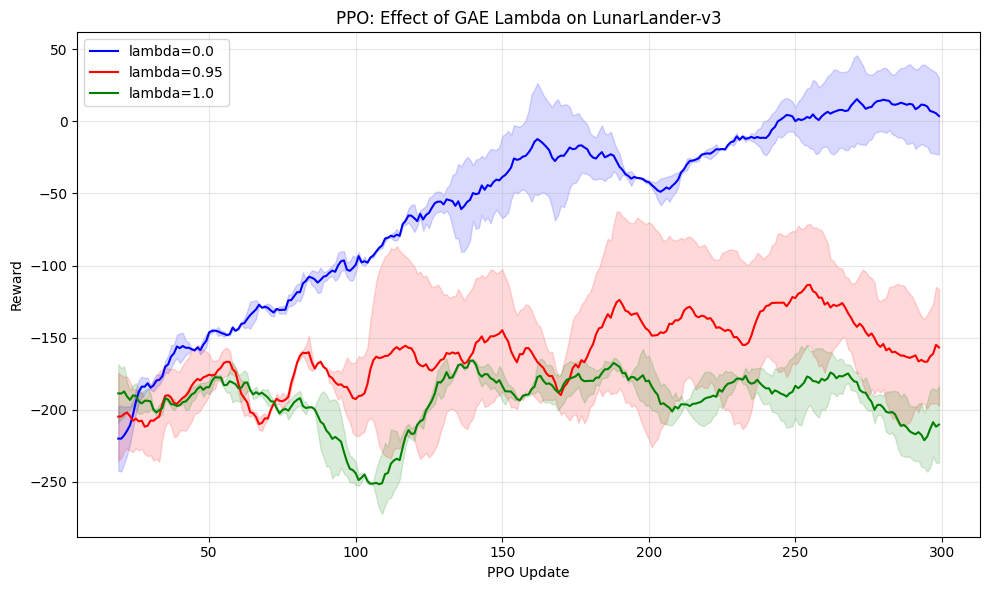

lambda=0.0: 3.7 ± 26.5
lambda=0.95: -156.8 ± 40.4
lambda=1.0: -210.3 ± 26.6


In [ ]:
seeds = [42, 123]
gae_lambdas = [0.0, 0.95, 1.0]  # TD (high bias), default, MC (no bias)

# No solve_threshold — we want the full learning curve for each lambda.
gae_results = {}
#DISCLAIMER: I changed the tests here because it took too long to train (several hours)
#I explain this further in the Summary section below, hope this was OK.
for lam in gae_lambdas:
    gae_results[f'lambda={lam}'] = [
        train_ppo(env_name='LunarLander-v3', num_updates=300, n_steps=1024, seed=s,
                  gae_lambda=lam, lr=3e-4, clip_eps=0.2, n_epochs=4,
                  batch_size=64, entropy_coef=0.01)
        for s in seeds
    ]

plot_comparison(gae_results, title='PPO: Effect of GAE Lambda on LunarLander-v3',
                window=20, x_label='PPO Update', reward_key='update_rewards')

for name, results_list in gae_results.items():
    final = [np.mean(r['update_rewards'][-20:]) for r in results_list]
    print(f'{name}: {np.mean(final):.1f} ± {np.std(final):.1f}')


---

## Summary

**TODO:** Write a brief summary of your findings (double-click to edit).

1. **B.1 — Baseline ablation:** Does the value baseline help REINFORCE on CartPole? Describe the difference in convergence speed and variance between the two variants.

We got the results:

REINFORCE (with baseline): 444.7 ± 74.8

REINFORCE (no baseline): 369.3 ± 169.1

The graph shows us that the convergence happens faster without the baseline, but that with baseline we get more of "slower, but steadier" training that in the end has better performance. We can also see that having baseline lowers the variance. It seems that our baseline which centers the rewards makes us have more stable training and as a result we get generally better performance. In contrast, the version without baseline is much more inconsistent and we have some runs that perform very well, while other runs fail miserably.

So to summarize, REINFORCE with baseline gives us lower variance, lower convergence speed but also a much more stable learning which in turn gives better performance. REINFORCE without baseline instead gives higher variance, converges faster but has more unstable training which eventually leads to a worse result.

2. **B.2 — GAE lambda:** Which λ value performed best on LunarLander-v3? Describe the bias-variance trade-off you observed — what happens at the extremes (λ = 0 and λ = 1) and why?

We got the results:

lambda=0.0: 3.7 ± 26.5

lambda=0.95: -156.8 ± 40.4

lambda=1.0: -210.3 ± 26.6

Using a low λ makes the agent rely on its estimate or future rewards (the value function). For this experiment it gave the most stable training. I think this is because our agent then avoids long and unpredictable trajectories. The value function estimates may not be correct early on, but having low variance makes the agent able to learn a stable policy pretty quickly.

Using a high λ makes the agent calculate the advantage while using the full return of the trajectory. This means that it is technically "unbiased" because it uses our real data, but the downside is massive variance. Every small random event in a LunarLunar update risks adding noise to our update of the gradients. This might make it difficult for the agent to actually figure out which specific action(s) that are good and which are bad.

I also want to note that I reduced the tests a bit because it took too long to train. (This was my fault really, and I did this because you have to click the screen every few minutes not to be logged out when using LiU's RDP client. In the future, I'll go to the actual lab rooms at campus and train my models there so I don't have to click the screen all the time for several hours in a row.) My point here is that I reduced the tests to 300 updates and 1024 number of steps, which may affect the result here. Primarily increasing the number of steps per update would probably counteract the high variance problem with the high λ tests. Also even though the convergence with high λ is slow, it would likely converge to better results at some point, potentially beating the low λ tests. So I can't really say if low or high λ is the best here, but it seems like two different strategies to calculate the update of gradients and it's likely situational which one should be chosen. It is however very clear that a low λ does converge much faster though.

---

**Lab designed by Amath Sow:** amath.sow@liu.se

**TDDE78 — Deep Reinforcement Learning, Linköping University, Spring 2026**